In [1]:
# ==============================
# STEP 1: Import Libraries
# ==============================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving
import joblib

# Machine Learning tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score, confusion_matrix

# CatBoost model
from catboost import CatBoostClassifier, Pool

In [2]:
# ==============================
# STEP 2: Load Dataset
# ==============================

# Read CSV file
df = pd.read_csv("K:\\Program Files\\Chrome-Download\\Healthcare-Diabetes.csv")

# Display first 5 rows
df.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ==============================
# STEP 3: Data Cleaning
# ==============================

# Remove duplicate rows
df = df.drop_duplicates()

# Remove ID column if exists
if 'Id' in df.columns:
    df.drop('Id', axis=1, inplace=True)

# Replace impossible zero values with NaN
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Fill missing values using median
df.fillna(df.median(numeric_only=True), inplace=True)

# Separate Features (X) and Target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [4]:
# ==============================
# STEP 4: Train-Test Split
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% training, 20% testing
    random_state=42,
    stratify=y            # Keeps class balance
)

In [5]:
# ==============================
# STEP 5: Define Base Models
# ==============================

# 1️. Naive Bayes with Scaling
nb_pipe = Pipeline([
    ('scaler', StandardScaler()),   # Feature scaling
    ('nb', GaussianNB())            # Naive Bayes classifier
])

# 2️. CatBoost Model
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_seed=42
)

In [6]:
# ==============================
# STEP 6: Stacking Model
# ==============================

# Combine Naive Bayes + CatBoost
estimators = [
    ('nb', nb_pipe),
    ('cat', cat_model)
]

# Logistic Regression acts as Meta-Learner
ensemble_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

In [7]:
# ==============================
# STEP 7: Training
# ==============================

print("Training Ensemble Model...")

ensemble_model.fit(X_train, y_train)

Training Ensemble Model...


,estimators,"[('nb', ...), ('cat', ...)]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,copy,True
,with_mean,True
,with_std,True
,priors,None


In [8]:
# ==============================
# STEP 8: Evaluation
# ==============================

# Predictions
y_pred = ensemble_model.predict(X_test)

# Accuracy
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

# Cross Validation Score
cv_scores = cross_val_score(ensemble_model, X, y, cv=5)
print("Cross Validation Mean:", cv_scores.mean())

Test Accuracy: 0.9494584837545126
Cross Validation Mean: 0.9678439232019637


Ensemble ROC-AUC Score: 0.9865287813883721


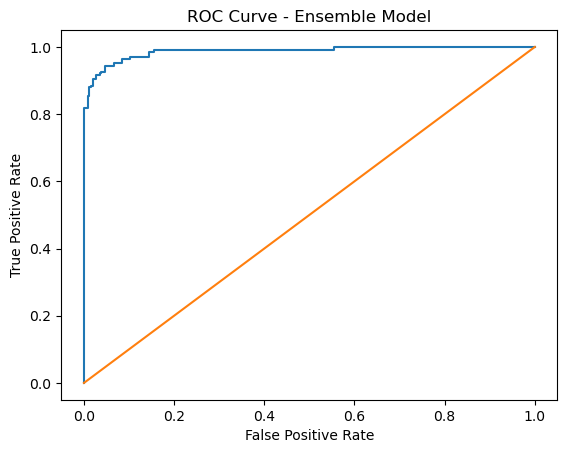

In [26]:
# ==============================
# ROC-AUC Using Ensemble Model
# ==============================

# Get probability predictions
y_prob = ensemble_model.predict_proba(X_test)[:, 1]

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

print("Ensemble ROC-AUC Score:", auc_score)

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title("ROC Curve - Ensemble Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       363
           1       0.94      0.92      0.93       191

    accuracy                           0.95       554
   macro avg       0.95      0.94      0.94       554
weighted avg       0.95      0.95      0.95       554



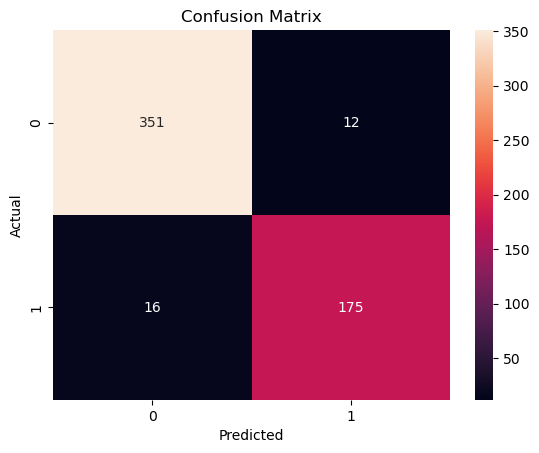

In [27]:
# ==============================
# STEP 10: Detailed Metrics
# ==============================

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
# ==============================
# STEP 11: Permutation Importance (For Ensemble Model)
# ==============================

from sklearn.inspection import permutation_importance

# Calculate permutation importance
result = permutation_importance(
    ensemble_model,      # Your stacking model
    X_test,              # Use test data
    y_test,
    n_repeats=10,        # Shuffle 10 times
    random_state=42,
    scoring="accuracy"
)

# Create DataFrame
perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

# Sort by importance
perm_importance = perm_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display values
print(perm_importance)

                    Feature  Importance
1                   Glucose    0.188989
5                       BMI    0.102347
7                       Age    0.085199
6  DiabetesPedigreeFunction    0.078520
0               Pregnancies    0.045848
2             BloodPressure    0.045307
4                   Insulin    0.043321
3             SkinThickness    0.020036


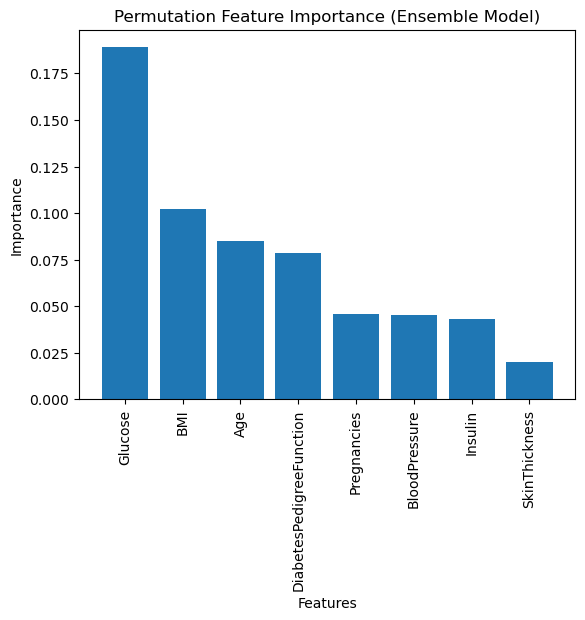

In [33]:
plt.figure()
plt.bar(perm_importance["Feature"], perm_importance["Importance"])
plt.xticks(rotation=90)
plt.title("Permutation Feature Importance (Ensemble Model)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [36]:
# ==============================
# STEP 12: Save Model
# ==============================

joblib.dump(ensemble_model, "model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


In [35]:
# ==============================
# STEP 13: New Prediction
# ==============================

# Example patient data
# (Pregnancies, Glucose, BloodPressure, SkinThickness,
#  Insulin, BMI, DiabetesPedigreeFunction, Age)

new_data = [[13, 145, 82, 19, 110, 22.2, 0.245, 57]]

prediction = cat_model.predict(new_data)

if prediction[0] == 1:
    print("Diabetic")
else:
    print("Non-Diabetic")

Non-Diabetic
